In [1]:
%load_ext autoreload
%autoreload 2

import pyttb as ttb
import numpy as np

# add common to python path
import os
import sys

import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals

import goated.rol_interface.models as rolm
import goated.rol_interface.objective as rolo
from goated.cp import GocchaObjective, CPGoal
from goated.rol_interface.FactorVector import FactorVector

# add ROL things
import copy
from pyrol import getCout, ParameterList, Problem, Solver


In [2]:
# Exodus file name with tensor data
# fname = '/Volumes/phited/DrekarData/TearingMode/john_2024_08_29/output_2D_TearingMode_64x32_S_1E3.exo'
# fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/1E3_2D_TearingMode.exo'
fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/output_2D_TearingMode_64x32_S_1E3.exo'


do_goal_plots = True  # construct goal plots
save_data = False     # save tensor reconstructions to disk
save_figs = False     # save figures
rank = 15             # Rank of the CP decomposition
maxiters = 30         # max iterations of gcp_opt
pgtol = 1e-2          # BFGS tolerance

In [3]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

In [4]:
# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind+mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]

In [5]:
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)
us0,_,_ = ttb.cp_als(Xs,rank=rank,maxiters=50)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()

CP_ALS:
 Iter 0: f = 5.860646e-01 f-delta = 5.9e-01
 Iter 1: f = 7.458769e-01 f-delta = 1.6e-01
 Iter 2: f = 7.928573e-01 f-delta = 4.7e-02
 Iter 3: f = 8.282425e-01 f-delta = 3.5e-02
 Iter 4: f = 8.447439e-01 f-delta = 1.7e-02
 Iter 5: f = 8.511002e-01 f-delta = 6.4e-03
 Iter 6: f = 8.546582e-01 f-delta = 3.6e-03
 Iter 7: f = 8.581979e-01 f-delta = 3.5e-03
 Iter 8: f = 8.662932e-01 f-delta = 8.1e-03
 Iter 9: f = 8.754183e-01 f-delta = 9.1e-03
 Iter 10: f = 8.824805e-01 f-delta = 7.1e-03
 Iter 11: f = 8.869144e-01 f-delta = 4.4e-03
 Iter 12: f = 8.899734e-01 f-delta = 3.1e-03
 Iter 13: f = 8.928636e-01 f-delta = 2.9e-03
 Iter 14: f = 8.960334e-01 f-delta = 3.2e-03
 Iter 15: f = 8.993278e-01 f-delta = 3.3e-03
 Iter 16: f = 9.023676e-01 f-delta = 3.0e-03
 Iter 17: f = 9.050241e-01 f-delta = 2.7e-03
 Iter 18: f = 9.073593e-01 f-delta = 2.3e-03
 Iter 19: f = 9.094412e-01 f-delta = 2.1e-03
 Iter 20: f = 9.112957e-01 f-delta = 1.9e-03
 Iter 21: f = 9.129287e-01 f-delta = 1.6e-03
 Iter 22: f 

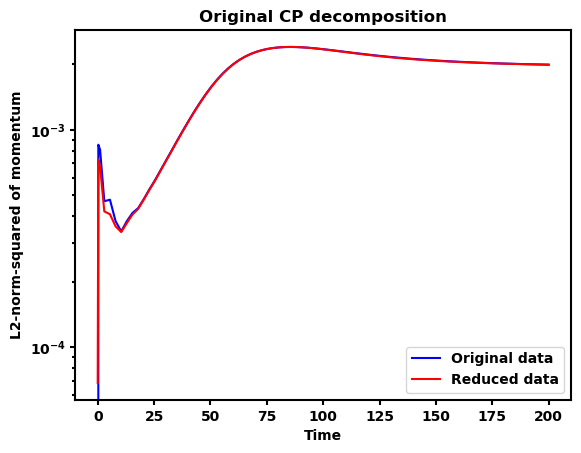

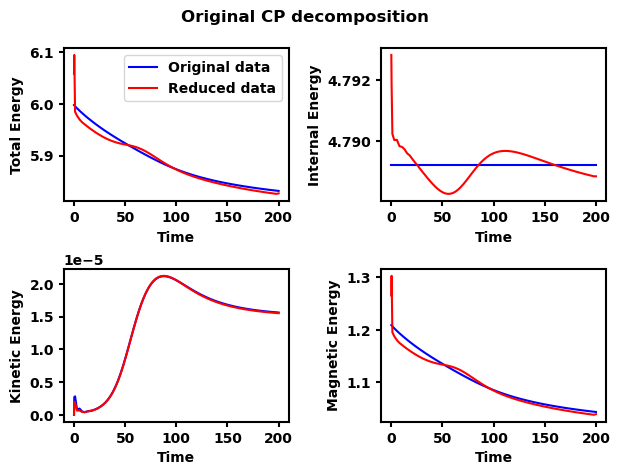

In [6]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original CP decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [7]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeValue(U0)
E_goal0 = E_goal.computeValue(U0)
T_goal0 = T_goal.computeValue(U0)
P_goal0 = P_goal.computeValue(U0)
B_goal0 = B_goal.computeValue(U0)

print(f'Initial fit = {fit0:.4f}, momentum goal = {mom_goal0:.2e}, total energy goal = {E_goal0:.2e}, internal energy goal = {T_goal0:.2e}, kinetic energy goal {P_goal0:.2e}, magnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9975, momentum goal = 4.23e-08, total energy goal = 1.82e-02, internal energy goal = 3.81e-05, kinetic energy goal 2.16e-12, magnetic energy goal = 1.74e-02


In [9]:
my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
goal = CPGoal(scaler, my_goals, weights)
a = 1/(ng*((Xs-us0.full()).norm()**2))
cp = GocchaObjective(Xs, goal, a, 1.0)
us0.normalize(weight_factor='all')

ktensor of shape (65, 33, 7, 83) with order F
weights=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
factor_matrices[0] =
[[-2.08861086e-03 -4.07177819e-02  9.35574544e-01 -7.66853831e-02
  -2.58776509e-01  5.16515275e-01  5.12153022e-01 -6.51597709e-04
  -4.98255311e-04  8.12031887e-04  1.44765361e-01  3.39064329e-01
  -3.80731330e-01  7.19892621e-01  5.71761125e-04]
 [ 7.80527019e-02 -6.17607821e-02  9.23405222e-01 -5.03519992e-02
  -2.51960724e-01  5.17450255e-01  5.13227204e-01 -8.15105302e-02
   6.44629025e-02  8.41276018e-02  1.50099042e-01  3.38103764e-01
  -3.84271688e-01  7.56548085e-01  1.45584240e-02]
 [ 1.55843113e-01 -9.86330423e-02  8.89676122e-01  2.24681709e-02
  -2.21137845e-01  5.20411645e-01  5.16271963e-01 -1.59961211e-01
   1.29200670e-01  1.63511623e-01  1.68320508e-01  3.35761799e-01
  -3.94432845e-01  7.76492514e-01  4.19143454e-02]
 [ 2.29365841e-01 -1.51527410e-01  8.40492456e-01  1.28567712e-01
  -1.65357342e-01  5.24997268e-01  5.20826247e-01 -2.33963301e-01

In [10]:
precondition = True

stream = getCout()

x = FactorVector(copy.deepcopy(us0.factor_matrices))
g = x.dual()

objective = rolo.GocchaRolObjective(precondition, cp)
problem = Problem(objective, x, g)
#problem.check(True, stream)

params = rolm.build_cp_parameter_list()
solver = Solver(problem,params)
solver.solve(stream)


Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.000000e+00   1.998709e+01   ---            1.425998e-02   2         1         ---       ---       ---       
  1     9.972257e-01   1.981632e+01   1.425998e-02   3.564995e-02   3         2         0         1         3         
  2     9.904036e-01   1.942001e+01   3.564995e-02   8.912488e-02   4         3         0         1         3         
  3     9.739563e-01   1.857905e+01   8.912488e-02   2.228122e-01   5         4         0         1         3         
  4     9.356290e-01   1.697866e+01   2.228122e-01   5.570305e-01   6         5         0         1         3         
  5     8.527560e-01   1.459974e+01   5.570305e-01   1.392576e+00   7         6         0         1         3         
  6     7.158030e-01   2.429783e+01   1.392576e+00   3.481441e+00   8         7         0         1         3         
  7     4.8326

0

   5.120307e+00   1.359938e+02   12        11        0         20        1         
Optimization Terminated with Status: Iteration Limit Exceeded


In [11]:
us1 = ttb.ktensor(x.data)
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeValue(U1)
E_goal1 = E_goal.computeValue(U1)
T_goal1 = T_goal.computeValue(U1)
P_goal1 = P_goal.computeValue(U1)
B_goal1 = B_goal.computeValue(U1)

print(f'Final fit = {fit1:.4f}, momentum goal = {mom_goal1:.2e}, total energy goal = {E_goal1:.2e}, internal energy goal = {T_goal1:.2e}, kinetic energy goal {P_goal1:.2e}, magnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9975, momentum goal = 2.32e-10, total energy goal = 5.30e-07, internal energy goal = 8.26e-08, kinetic energy goal 7.15e-15, magnetic energy goal = 5.68e-07


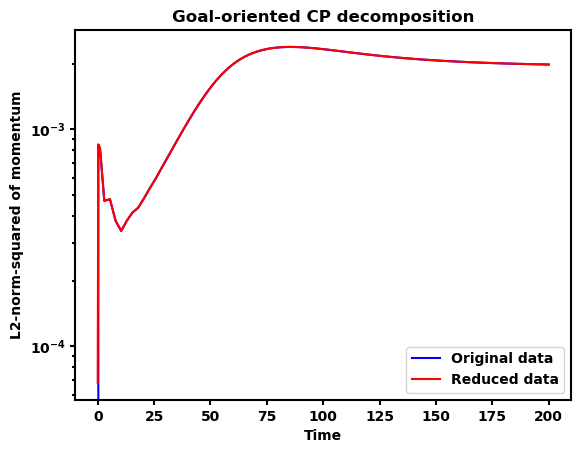

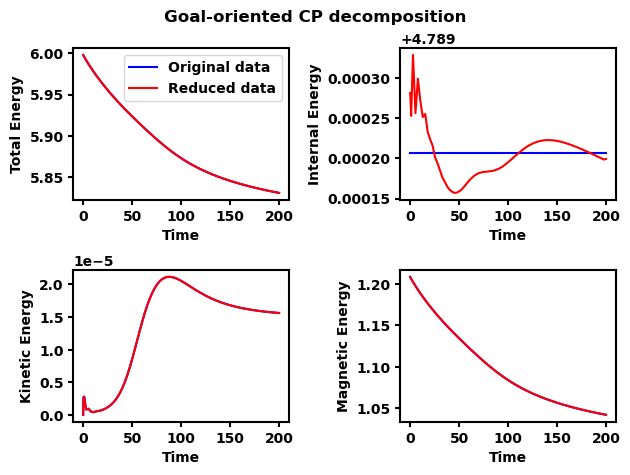

In [12]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented CP decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')